<a href="https://colab.research.google.com/github/Sadeemalj6/SDA_BOOTCAMP/blob/main/clothing_classifier_resnet50_gradio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ♻️ Second-Hand Clothing Classifier — Baseline CNN vs ResNet50 vs ViT + Gradio

**Run All** من الأعلى للأسفل (يفضّل Runtime ▸ Change runtime type ▸ **GPU**).

الخطوات: تحميل الـ Dataset → تجهيز الـ labels والـ splits → تدريب وتقييم Baseline CNN و ResNet50 → **حفظ ResNet50 والتحقق منه** → ViT → المقارنة → واجهة Gradio (Upload + Webcam).

الـ Dataset يتم تحميله تلقائيًا من Hugging Face Hub: `wargoninnovation/clothingdatasetsecondhand` (لا يوجد أي ملف خارجي مطلوب).

## 1. Install dependencies

In [1]:
!pip install -q transformers datasets scikit-learn matplotlib seaborn pillow torchvision gradio

## 2. Imports, device and run settings

In [2]:
import io
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset as TorchDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Using:", device)
if device.type == "cpu":
    print("⚠️ No GPU detected. Training will be VERY slow. Use Runtime > Change runtime type > GPU.")

# ---- Run settings -------------------------------------------------------
RUN_BASELINE_CNN = True    # train + evaluate Baseline CNN
RUN_VIT = True             # train + evaluate ViT
MODEL_PATH = "clothing_resnet50.pth"   # where the final ResNet50 weights are saved
NUM_WORKERS = 2            # DataLoader workers (data loading speed only)

PyTorch: 2.11.0+cu130
Using: cuda


## 3. Dataset loading

In [3]:
from datasets import load_dataset

try:
    dataset = load_dataset("wargoninnovation/clothingdatasetsecondhand")
except Exception as e:
    raise RuntimeError(
        "Could not download the dataset 'wargoninnovation/clothingdatasetsecondhand' from Hugging Face Hub. "
        "Check the Colab internet connection and re-run this cell."
    ) from e

print(dataset)

README.md:   0%|          | 0.00/15.0k [00:00<?, ?B/s]

data/train-00000-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  448MB            

data/train-00000-of-00004.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  448MB            

data/train-00001-of-00004.parquet: downloading bytes:           |  0.00B            

...

data/test-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  384MB            

data/test-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/30192 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12940 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['filename', 'image_type', 'brand_missing', 'sizetext', 'cut', 'stains', 'price', 'smell', 'price_confidence', 'damage3', 'season', 'condition', 'usage_confidence', 'damage3loc', 'annotator', 'pattern', 'comment', 'material', 'pilling', 'weight', 'damageimage', 'size', 'damage2loc', 'holes', 'brandtext', 'colors', 'damageloc', 'description', 'trend', 'category', 'damage2', 'usage', 'brand', 'damage2image', 'type', 'damage', 'damage3image', 'styleholes', 'image'],
        num_rows: 30192
    })
    test: Dataset({
        features: ['filename', 'image_type', 'brand_missing', 'sizetext', 'cut', 'stains', 'price', 'smell', 'price_confidence', 'damage3', 'season', 'condition', 'usage_confidence', 'damage3loc', 'annotator', 'pattern', 'comment', 'material', 'pilling', 'weight', 'damageimage', 'size', 'damage2loc', 'holes', 'brandtext', 'colors', 'damageloc', 'description', 'trend', 'category', 'damage2', 'usage', 'brand', 'damage2image', 

## 4. Dataset inspection

In [4]:
for split in dataset:
    print(split, len(dataset[split]))

print()
print(dataset["train"].column_names)

df = dataset["train"].to_pandas()
df.head()

train 30192
test 12940

['filename', 'image_type', 'brand_missing', 'sizetext', 'cut', 'stains', 'price', 'smell', 'price_confidence', 'damage3', 'season', 'condition', 'usage_confidence', 'damage3loc', 'annotator', 'pattern', 'comment', 'material', 'pilling', 'weight', 'damageimage', 'size', 'damage2loc', 'holes', 'brandtext', 'colors', 'damageloc', 'description', 'trend', 'category', 'damage2', 'usage', 'brand', 'damage2image', 'type', 'damage', 'damage3image', 'styleholes', 'image']


,filename,image_type,brand_missing,sizetext,cut,stains,price,smell,price_confidence,damage3,...,category,damage2,usage,brand,damage2image,type,damage,damage3image,styleholes,image
0,front_2023_09_13_05_18_15.png,front,False,,1,1,<50,2,High,,...,0,,2,0,front,14,,front,False,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...
1,front_2023_11_06_07_07_20.png,front,False,,1,2,<50,2,High,,...,3,fläckar,0,7,front,20,,front,True,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...
2,front_2023_06_29_13_15_53.png,front,False,,1,1,<50,2,High,,...,3,,2,20,front,14,,front,False,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...
3,back_2023_12_27_12_24_34.png,back,False,,1,1,<50,2,High,nopprigt,...,1,nopprigt,2,7,back,7,nopprigt,front,False,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...
4,front_2023_12_21_12_28_39.png,front,True,,1,1,50-100,2,High,,...,1,,1,0,front,20,,front,False,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30192 entries, 0 to 30191
Data columns (total 39 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   filename          30192 non-null  object 
 1   image_type        30192 non-null  object 
 2   brand_missing     30192 non-null  bool   
 3   sizetext          30192 non-null  object 
 4   cut               30192 non-null  int64  
 5   stains            30192 non-null  int64  
 6   price             30192 non-null  object 
 7   smell             30192 non-null  int64  
 8   price_confidence  30192 non-null  object 
 9   damage3           30192 non-null  object 
 10  season            30192 non-null  int64  
 11  condition         30192 non-null  int64  
 12  usage_confidence  30192 non-null  object 
 13  damage3loc        30192 non-null  object 
 14  annotator         30192 non-null  float64
 15  pattern           30192 non-null  int64  
 16  comment           30192 non-null  object

usage
1    14577
0    12283
2     2808
4      197
5      181
3      108
6       16
7       11
8        9
9        2
Name: count, dtype: int64


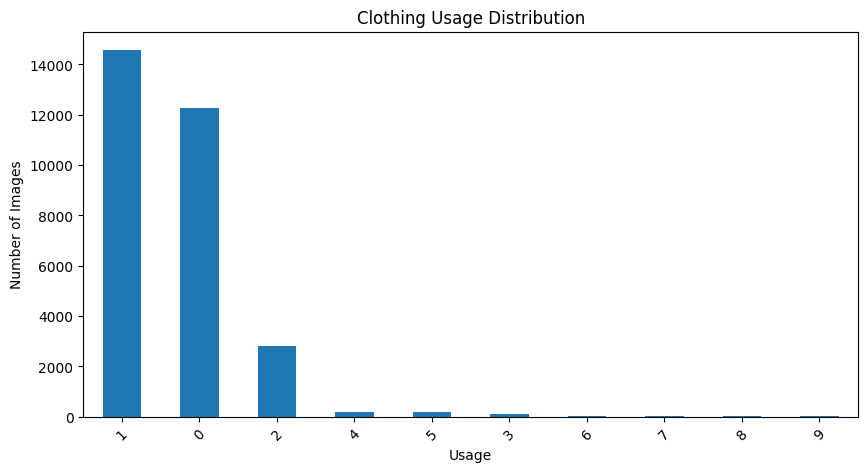

In [6]:
usage_counts = df["usage"].value_counts()
print(usage_counts)

plt.figure(figsize=(10, 5))
usage_counts.plot(kind="bar")
plt.title("Clothing Usage Distribution")
plt.xlabel("Usage")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

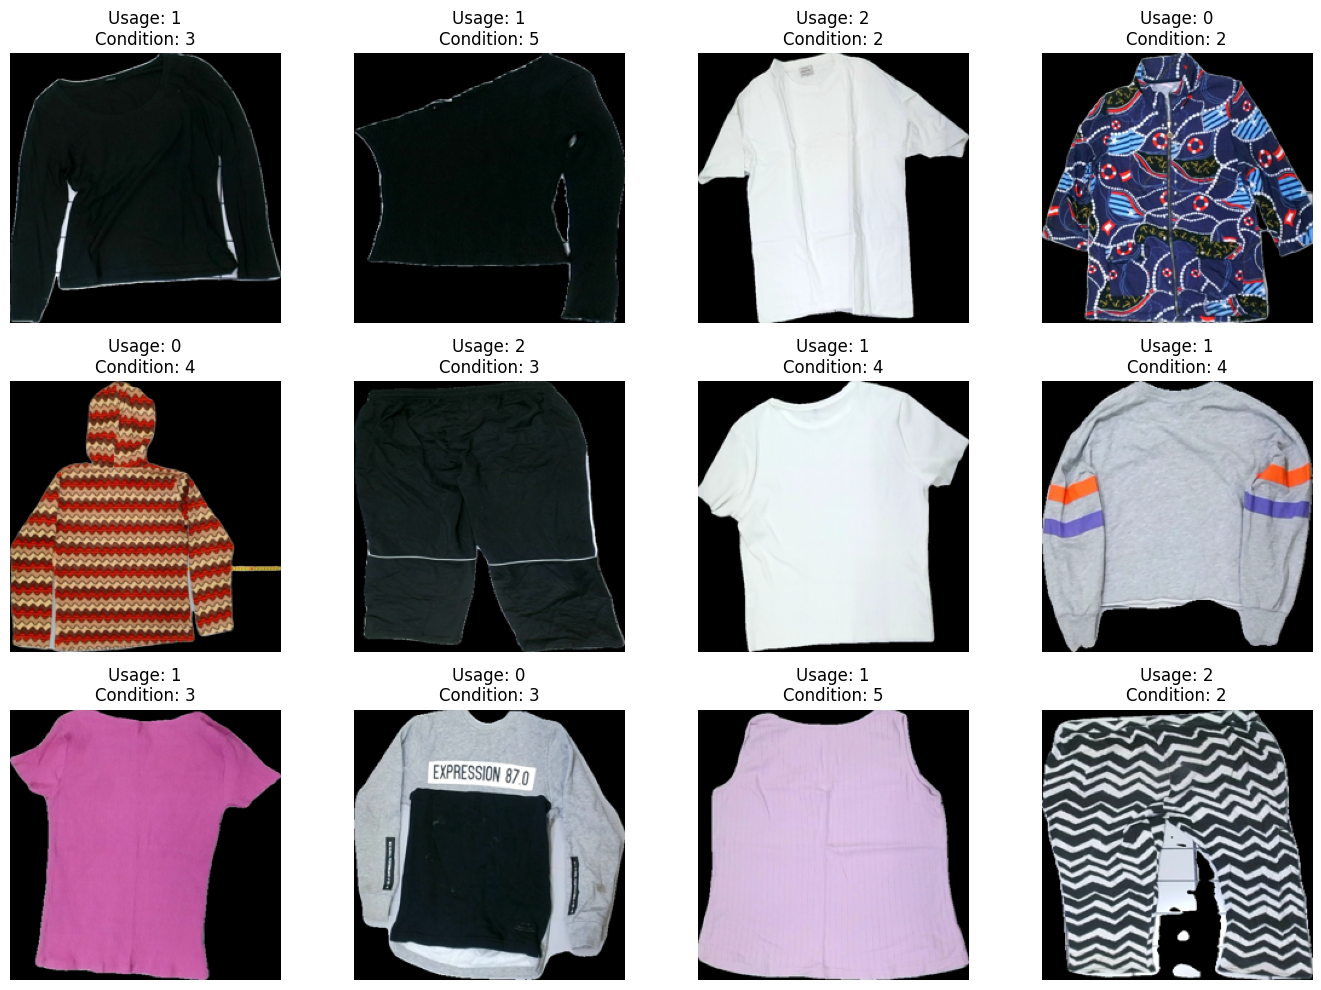

In [7]:
samples = df.sample(12, random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    image = Image.open(io.BytesIO(row["image"]["bytes"]))

    ax.imshow(image)
    ax.set_title(
        f"Usage: {row['usage']}\n"
        f"Condition: {row['condition']}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


condition
condition
3    10113
5     8047
2     6150
4     4649
1     1233
Name: count, dtype: int64

damage
damage
                 22027
fläckar            587
0                  567
stain              402
fläck              333
stained            309
nopprigt           294
hål                254
stains             230
smuts fläckar      179
smuts fläck        133
1                  132
hole               114
luddigt             86
smutsigt            85
Name: count, dtype: int64

holes
holes
0    28348
2     1004
1      838
3        2
Name: count, dtype: int64

stains
stains
1    19264
0     4582
2     3316
7     2041
6      982
5        3
3        2
4        1
8        1
Name: count, dtype: int64


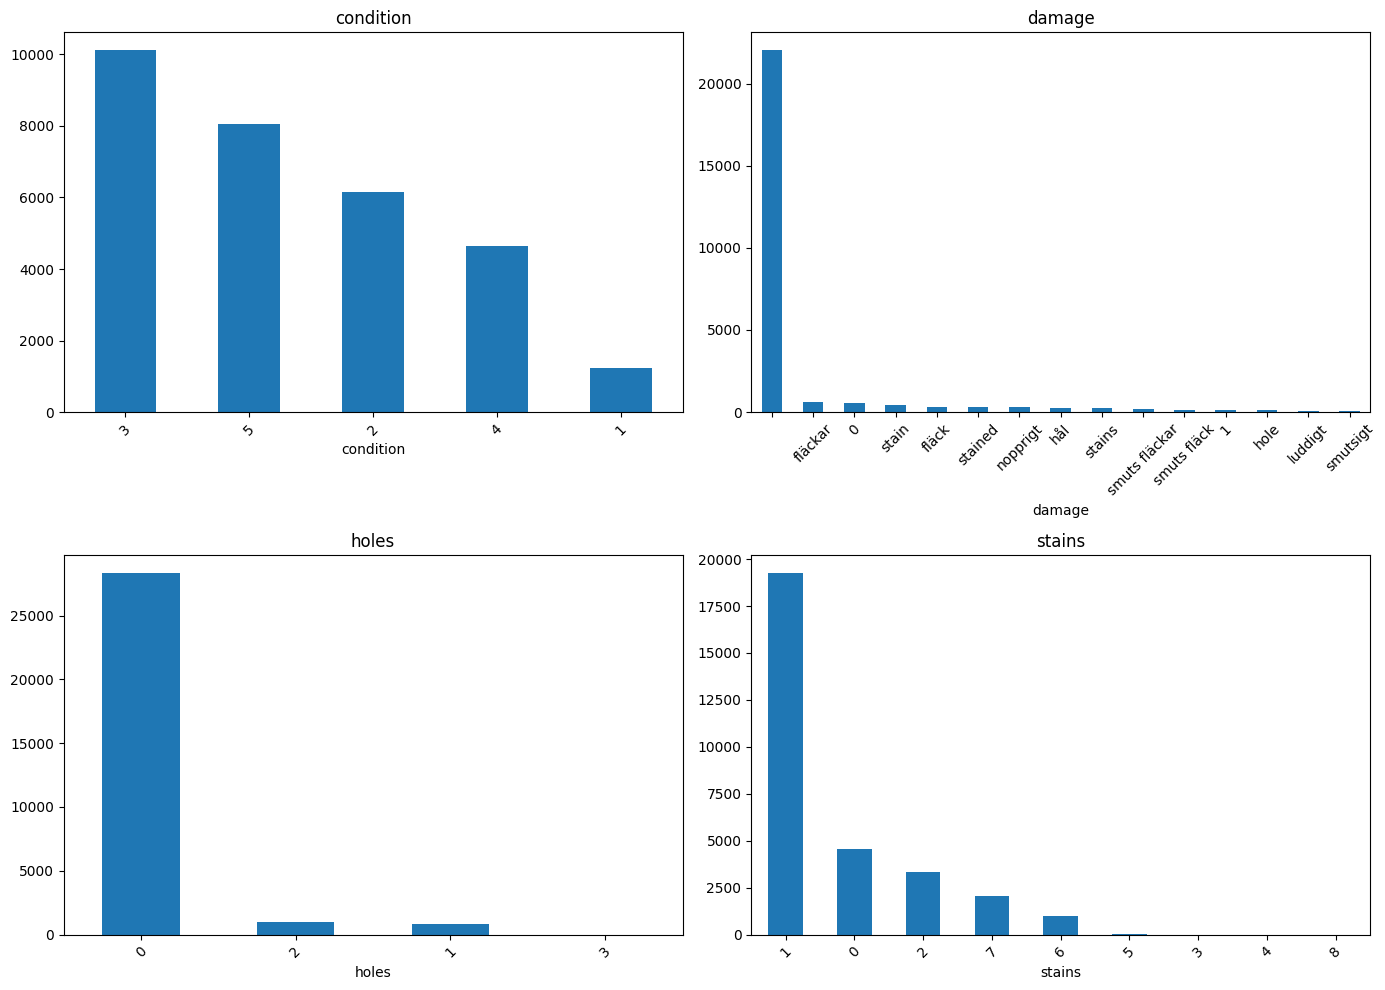

In [8]:
for column in ["condition", "damage", "holes", "stains"]:
    print("\n", "=" * 50)
    print(column)
    print(df[column].value_counts().head(15))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, column in zip(axes.flat, ["condition", "damage", "holes", "stains"]):
    df[column].value_counts().head(15).plot(kind="bar", ax=ax)   # top 15 (damage has 1000+ free-text values)
    ax.set_title(column)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 5. Label mapping

`usage` في الـ Dataset عبارة عن ClassLabel (0 = Export, 1 = Reuse, ...). يتم تحويل الأرقام إلى أسماء، ثم توحيد الحروف (capitalize) حتى تطابق الـ mapping، ثم تحويلها إلى 4 classes.

{'Donation Ready': 0, 'Minor Modification': 1, 'Transform': 2, 'Not Suitable': 3}
{0: 'Donation Ready', 1: 'Minor Modification', 2: 'Transform', 3: 'Not Suitable'}
Usage mapping in dataset features: {0: 'Export', 1: 'Reuse', 2: 'Recycle', 3: 'Energy recovery', 4: 'Remake', 5: 'Repair', 6: 'export', 7: 'recycle', 8: 'reuse', 9: 'Rcycle'}

Rows without a valid label (dropped): 2

Label counts:
 label
Donation Ready        26885
Not Suitable           2927
Transform               197
Minor Modification      181
Name: count, dtype: int64


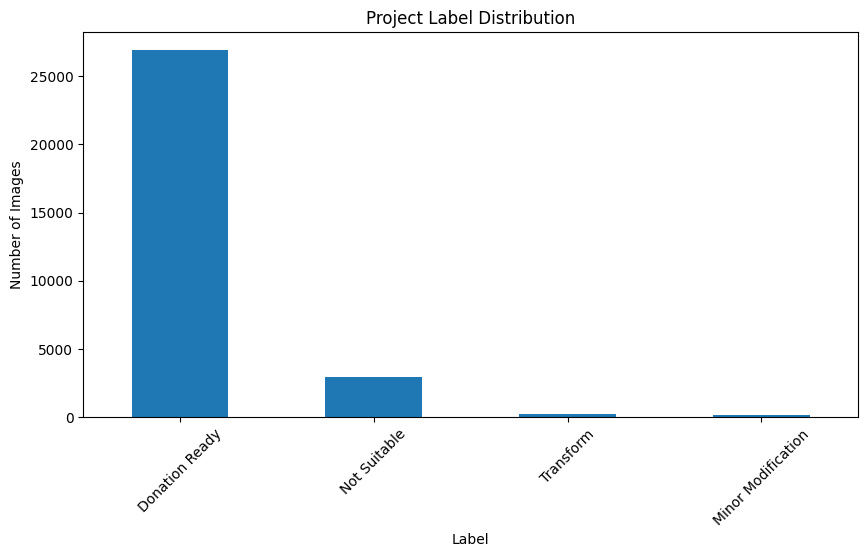

In [9]:
label_mapping = {
    "Reuse": "Donation Ready",
    "Export": "Donation Ready",
    "Repair": "Minor Modification",
    "Remake": "Transform",
    "Recycle": "Not Suitable",
    "Energy recovery": "Not Suitable"
}

label_names = [
    "Donation Ready",
    "Minor Modification",
    "Transform",
    "Not Suitable"
]

label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}

print(label2id)
print(id2label)

# usage id -> usage name (from the dataset features), then normalize capitalization
usage_names = dataset["train"].features["usage"].names
print("Usage mapping in dataset features:", {i: name for i, name in enumerate(usage_names)})

df["usage_name"] = df["usage"].apply(lambda x: usage_names[x] if x < len(usage_names) else None)
df["usage_name_clean"] = df["usage_name"].str.capitalize().str.strip()

df["label"] = df["usage_name_clean"].map(label_mapping)
df["label_id"] = df["label"].map(label2id)

print("\nRows without a valid label (dropped):", int(df["label_id"].isna().sum()))

clean_df = df.dropna(subset=["label_id"]).copy()
clean_df["label_id"] = clean_df["label_id"].astype(int)

label_counts = clean_df["label"].value_counts()
print("\nLabel counts:\n", label_counts)

plt.figure(figsize=(10, 5))
label_counts.plot(kind="bar")
plt.title("Project Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

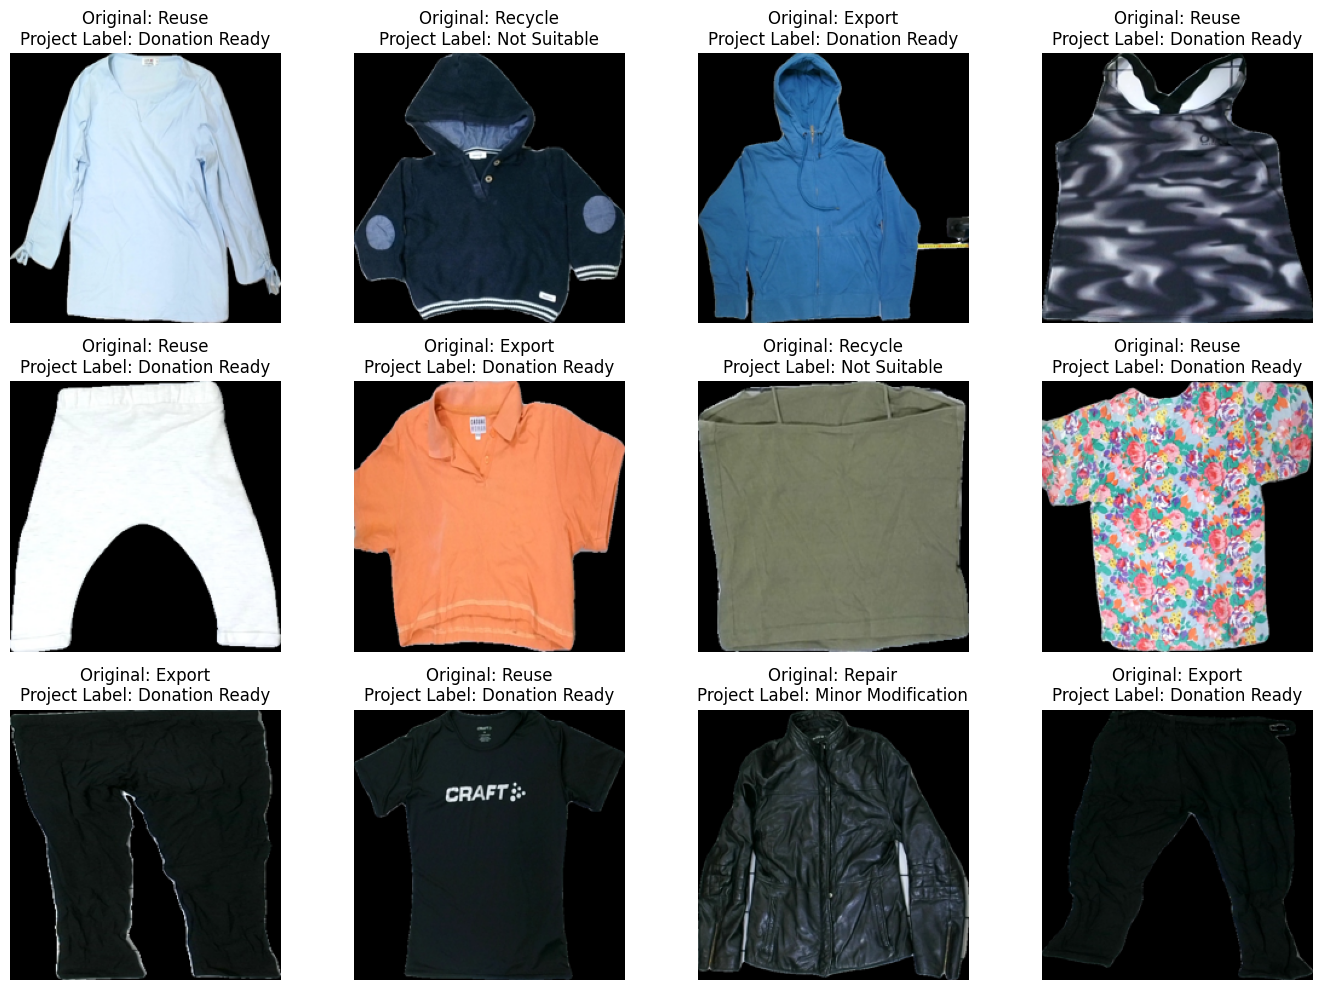

In [10]:
samples = clean_df.sample(12, random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    image = Image.open(io.BytesIO(row["image"]["bytes"]))

    ax.imshow(image)
    ax.set_title(
        f"Original: {row['usage_name']}\n"
        f"Project Label: {row['label']}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Train / validation / test split

Train size: 21133
Validation size: 4528
Test size: 4529

TRAIN
label
Donation Ready        18819
Not Suitable           2049
Transform               138
Minor Modification      127
Name: count, dtype: int64

VALIDATION
label
Donation Ready        4033
Not Suitable           439
Transform               29
Minor Modification      27
Name: count, dtype: int64

TEST
label
Donation Ready        4033
Not Suitable           439
Transform               30
Minor Modification      27
Name: count, dtype: int64


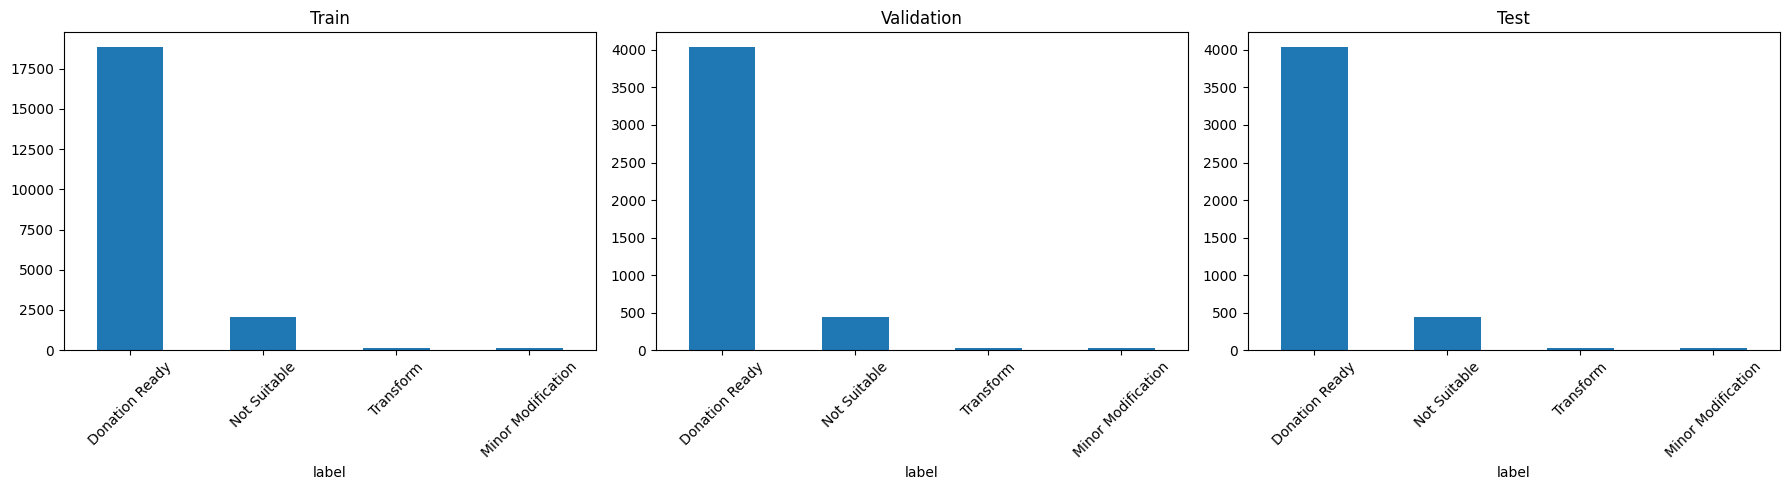

In [11]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.30,
    random_state=42,
    stratify=clean_df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label_id"]
)

# keep only the columns that are needed from here on (saves memory)
keep_cols = ["image", "label", "label_id"]
train_df = train_df[keep_cols].reset_index(drop=True)
val_df = val_df[keep_cols].reset_index(drop=True)
test_df = test_df[keep_cols].reset_index(drop=True)

del df, clean_df, temp_df, samples
gc.collect()

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

for name, part in [("TRAIN", train_df), ("VALIDATION", val_df), ("TEST", test_df)]:
    print("\n" + name)
    print(part["label"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, part) in zip(axes, [("Train", train_df), ("Validation", val_df), ("Test", test_df)]):
    part["label"].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 7. Preprocessing / transforms, Dataset class and DataLoaders

In [12]:
from torchvision import transforms

IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


def get_image(image_data):
    if isinstance(image_data, dict):
        if image_data.get("bytes") is not None:
            return Image.open(io.BytesIO(image_data["bytes"])).convert("RGB")
        elif image_data.get("path") is not None:
            return Image.open(image_data["path"]).convert("RGB")
        raise ValueError("Image dict has neither bytes nor path")

    elif isinstance(image_data, Image.Image):
        return image_data.convert("RGB")

    else:
        raise ValueError("Unknown image format")


class ClothingDataset(TorchDataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = get_image(row["image"])
        label = int(row["label_id"])

        if self.transform:
            image = self.transform(image)

        return image, label


train_torch = ClothingDataset(train_df, transform=train_transform)
val_torch = ClothingDataset(val_df, transform=test_transform)
test_torch = ClothingDataset(test_df, transform=test_transform)

BATCH_SIZE = 32
pin = device.type == "cuda"

train_loader = DataLoader(train_torch, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=pin)
val_loader = DataLoader(val_torch, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=pin)
test_loader = DataLoader(test_torch, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=pin)

images, labels = next(iter(train_loader))
print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])


## 8. Training and evaluation helpers

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    jaccard_score
)


def train_model(model, train_loader, val_loader, epochs=10):
    # Standard training (no class weights) - used for the Baseline CNN

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):

        # --------------------  Training  --------------------
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # --------------------  Validation  --------------------
        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                predictions = outputs.argmax(dim=1)
                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return model, history


def compute_metrics(all_labels, all_predictions):
    labels_range = list(range(len(label_names)))

    iou_per_class = jaccard_score(
        all_labels, all_predictions,
        average=None, labels=labels_range, zero_division=0
    )

    return {
        "accuracy": accuracy_score(all_labels, all_predictions),
        "precision": precision_score(all_labels, all_predictions, average="macro", zero_division=0),
        "recall": recall_score(all_labels, all_predictions, average="macro", zero_division=0),
        "f1": f1_score(all_labels, all_predictions, average="macro", zero_division=0),
        "iou_per_class": iou_per_class,
        "mean_iou": np.mean(iou_per_class),
        "confusion_matrix": confusion_matrix(all_labels, all_predictions, labels=labels_range),
        "predictions": all_predictions,
        "labels": all_labels
    }


def evaluate_model(model, test_loader):
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())

    return compute_metrics(all_labels, all_predictions)


def plot_history(history, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history["train_acc"], label="Training Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(history["train_loss"], label="Training Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


def report_results(results, title):
    print(f"{title} - Test Results")
    print("-" * 30)
    print(f"Accuracy:  {results['accuracy']:.4f}")
    print(f"Precision: {results['precision']:.4f}")
    print(f"Recall:    {results['recall']:.4f}")
    print(f"F1 Score:  {results['f1']:.4f}")
    print(f"Mean IoU:  {results['mean_iou']:.4f}")

    print("\nIoU per class:")
    for label, iou in zip(label_names, results["iou_per_class"]):
        print(f"  {label}: {iou:.4f}")

    print()
    print(classification_report(
        results["labels"], results["predictions"],
        target_names=label_names, zero_division=0
    ))

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        results["confusion_matrix"], annot=True, fmt="d",
        xticklabels=label_names, yticklabels=label_names
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{title} Confusion Matrix")
    plt.show()


all_results = {}   # model name -> test results (used in the final comparison)

## 9. Baseline CNN — model, training and evaluation

In [14]:
class BaselineCNN(nn.Module):

    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Epoch 1/10 | Train Loss: 0.4209 | Train Acc: 0.8900 | Val Loss: 0.3951 | Val Acc: 0.8907
Epoch 2/10 | Train Loss: 0.4048 | Train Acc: 0.8905 | Val Loss: 0.3999 | Val Acc: 0.8907
Epoch 3/10 | Train Loss: 0.4024 | Train Acc: 0.8905 | Val Loss: 0.3878 | Val Acc: 0.8907
Epoch 4/10 | Train Loss: 0.3993 | Train Acc: 0.8905 | Val Loss: 0.3933 | Val Acc: 0.8907
Epoch 5/10 | Train Loss: 0.4000 | Train Acc: 0.8905 | Val Loss: 0.3890 | Val Acc: 0.8907
Epoch 6/10 | Train Loss: 0.4007 | Train Acc: 0.8903 | Val Loss: 0.4519 | Val Acc: 0.8907
Epoch 7/10 | Train Loss: 0.4066 | Train Acc: 0.8905 | Val Loss: 0.3971 | Val Acc: 0.8907
Epoch 8/10 | Train Loss: 0.4001 | Train Acc: 0.8903 | Val Loss: 0.3929 | Val Acc: 0.8907
Epoch 9/10 | Train Loss: 0.4000 | Train Acc: 0.8905 | Val Loss: 0.3923 | Val Acc: 0.8907
Epoch 10/10 | Train Loss: 0.3989 | Train Acc: 0.8905 | Val Loss: 0.3946 | Val Acc: 0.8907


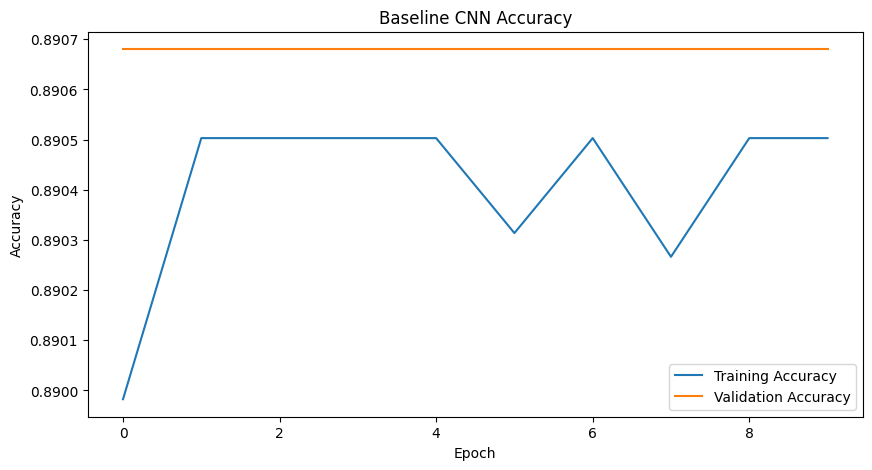

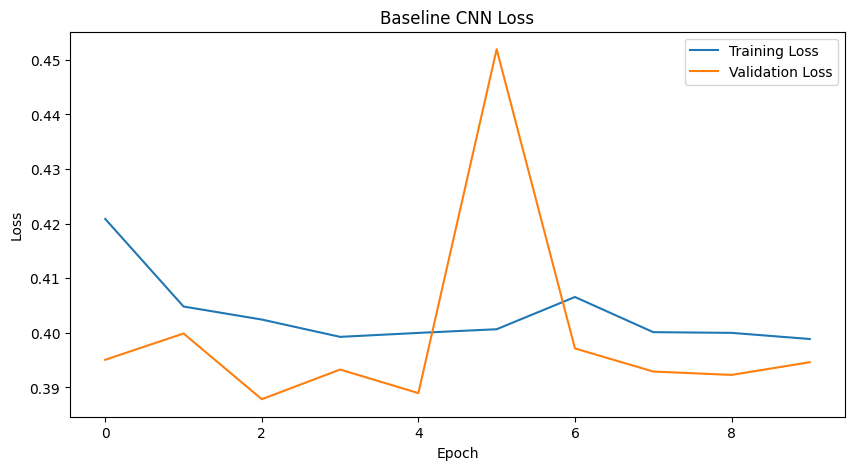

In [15]:
if RUN_BASELINE_CNN:
    baseline_model = BaselineCNN(num_classes=4)

    baseline_model, baseline_history = train_model(
        baseline_model,
        train_loader,
        val_loader,
        epochs=10
    )

    plot_history(baseline_history, "Baseline CNN")
else:
    print("RUN_BASELINE_CNN = False -> skipped.")

Baseline CNN - Test Results
------------------------------
Accuracy:  0.8905
Precision: 0.2226
Recall:    0.2500
F1 Score:  0.2355
Mean IoU:  0.2226

IoU per class:
  Donation Ready: 0.8905
  Minor Modification: 0.0000
  Transform: 0.0000
  Not Suitable: 0.0000

                    precision    recall  f1-score   support

    Donation Ready       0.89      1.00      0.94      4033
Minor Modification       0.00      0.00      0.00        27
         Transform       0.00      0.00      0.00        30
      Not Suitable       0.00      0.00      0.00       439

          accuracy                           0.89      4529
         macro avg       0.22      0.25      0.24      4529
      weighted avg       0.79      0.89      0.84      4529



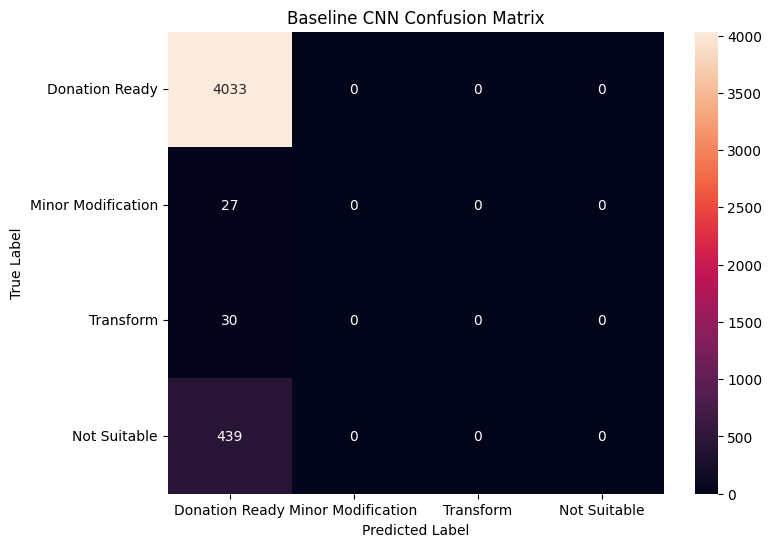

In [16]:
if RUN_BASELINE_CNN:
    baseline_results = evaluate_model(baseline_model, test_loader)
    all_results["Baseline CNN"] = baseline_results
    report_results(baseline_results, "Baseline CNN")

    del baseline_model            # free GPU memory before ResNet50
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

## 10. ResNet50 — training and evaluation

ResNet50 (ImageNet weights) مع class weights = `1 / sqrt(count)` لمعالجة عدم توازن الـ classes، `lr = 0.0001`, `epochs = 10`.

In [17]:
from torchvision.models import resnet50, ResNet50_Weights


def build_resnet50(pretrained=True, num_classes=4):
    weights = ResNet50_Weights.DEFAULT if pretrained else None
    model = resnet50(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


# class weights (computed from the TRAIN split only)
class_counts = train_df["label_id"].value_counts().sort_index()
print(class_counts)

class_weights = 1 / np.sqrt(class_counts.values)
class_weights = class_weights / class_weights.mean()

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("\nClass weights:")
for label, weight in zip(label_names, class_weights):
    print(label, ":", round(weight.item(), 3))

label_id
0    18819
1      127
2      138
3     2049
Name: count, dtype: int64

Class weights:
Donation Ready : 0.143
Minor Modification : 1.746
Transform : 1.675
Not Suitable : 0.435


In [18]:
def train_weighted_model(model, train_loader, val_loader, epochs=10, learning_rate=0.0001):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):

        # =========================  TRAIN  =========================
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # =========================  VALIDATION  =========================
        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                predictions = outputs.argmax(dim=1)
                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return model, history

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 101MB/s] 


Epoch 1/10 | Train Loss: 0.8740 | Train Acc: 0.8859 | Val Loss: 0.8280 | Val Acc: 0.8863
Epoch 2/10 | Train Loss: 0.8089 | Train Acc: 0.8832 | Val Loss: 0.8086 | Val Acc: 0.8732
Epoch 3/10 | Train Loss: 0.7549 | Train Acc: 0.8784 | Val Loss: 0.8028 | Val Acc: 0.8732
Epoch 4/10 | Train Loss: 0.6991 | Train Acc: 0.8716 | Val Loss: 0.8421 | Val Acc: 0.8708
Epoch 5/10 | Train Loss: 0.6421 | Train Acc: 0.8662 | Val Loss: 0.8353 | Val Acc: 0.8635
Epoch 6/10 | Train Loss: 0.5853 | Train Acc: 0.8658 | Val Loss: 0.8833 | Val Acc: 0.8598
Epoch 7/10 | Train Loss: 0.5054 | Train Acc: 0.8708 | Val Loss: 0.9345 | Val Acc: 0.8317
Epoch 8/10 | Train Loss: 0.4464 | Train Acc: 0.8755 | Val Loss: 0.9597 | Val Acc: 0.7683
Epoch 9/10 | Train Loss: 0.3831 | Train Acc: 0.8870 | Val Loss: 0.9679 | Val Acc: 0.8377
Epoch 10/10 | Train Loss: 0.3268 | Train Acc: 0.9031 | Val Loss: 1.0338 | Val Acc: 0.8052


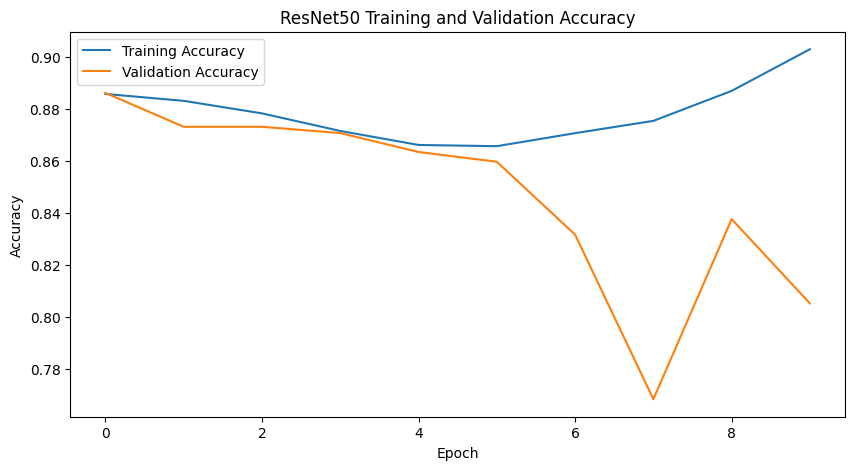

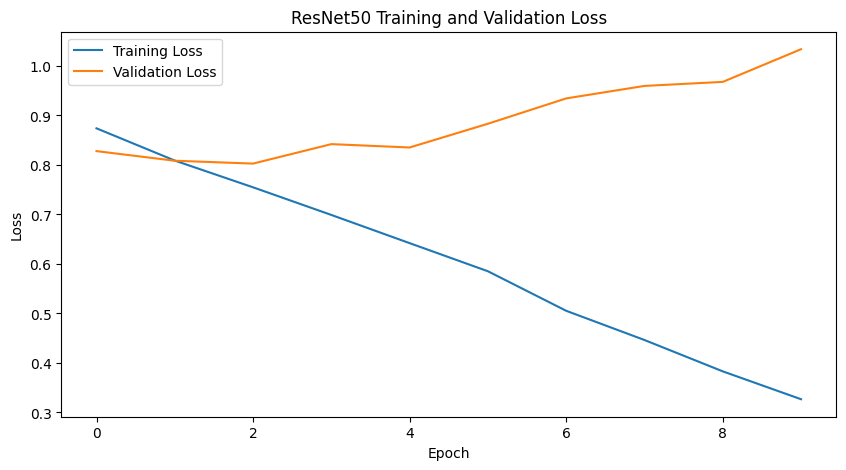

In [19]:
resnet_model = build_resnet50(pretrained=True, num_classes=4)

resnet_model, resnet_history = train_weighted_model(
    resnet_model,
    train_loader,
    val_loader,
    epochs=10,
    learning_rate=0.0001
)

plot_history(resnet_history, "ResNet50 Training and Validation")

ResNet50 - Test Results
------------------------------
Accuracy:  0.8159
Precision: 0.3848
Recall:    0.3977
F1 Score:  0.3884
Mean IoU:  0.2961

IoU per class:
  Donation Ready: 0.8122
  Minor Modification: 0.1364
  Transform: 0.0769
  Not Suitable: 0.1590

                    precision    recall  f1-score   support

    Donation Ready       0.92      0.88      0.90      4033
Minor Modification       0.26      0.22      0.24        27
         Transform       0.12      0.17      0.14        30
      Not Suitable       0.24      0.32      0.27       439

          accuracy                           0.82      4529
         macro avg       0.38      0.40      0.39      4529
      weighted avg       0.84      0.82      0.83      4529



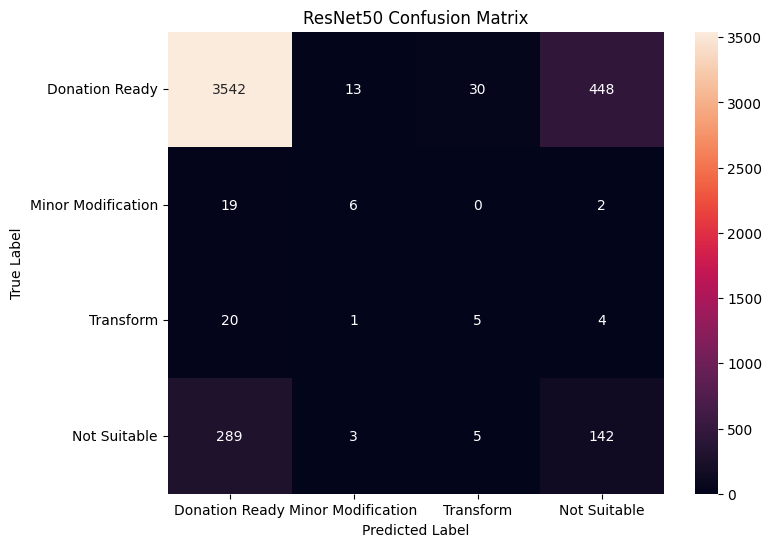

In [20]:
resnet_results = evaluate_model(resnet_model, test_loader)
all_results["ResNet50"] = resnet_results
report_results(resnet_results, "ResNet50")

## 11. Save ResNet50 and verify the saved file

يتم الحفظ مباشرة بعد التدريب (قبل ViT) حتى لا يضيع الموديل لو حصل أي مشكلة لاحقًا، ثم يتم التحقق فعليًا من وجود الملف ومن أنه يعطي نفس نتائج الموديل المدرَّب.

In [21]:
torch.save(resnet_model.state_dict(), MODEL_PATH)
print("torch.save finished.")

torch.save finished.


In [22]:
# 1) the file really exists and is not empty
assert os.path.exists(MODEL_PATH), f"❌ {MODEL_PATH} was NOT created!"
size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
assert size_mb > 1, f"❌ {MODEL_PATH} is suspiciously small ({size_mb:.2f} MB)"
print("✅ File exists:", os.path.abspath(MODEL_PATH), f"({size_mb:.1f} MB)")

# 2) the file loads into a fresh ResNet50 (no pretrained weights) ...
verify_model = build_resnet50(pretrained=False, num_classes=4)
verify_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
verify_model = verify_model.to(device).eval()

# 3) ... and gives the same outputs as the trained model
sample_images, _ = next(iter(test_loader))
sample_images = sample_images.to(device)

resnet_model.eval()
with torch.no_grad():
    out_trained = resnet_model(sample_images)
    out_loaded = verify_model(sample_images)

assert torch.allclose(out_trained, out_loaded, atol=1e-4), "❌ Loaded model outputs differ from the trained model!"
print("✅ Saved model loads correctly and reproduces the trained model outputs.")

del verify_model, sample_images, out_trained, out_loaded
gc.collect()

✅ File exists: /content/clothing_resnet50.pth (90.0 MB)
✅ Saved model loads correctly and reproduces the trained model outputs.


5557

In [23]:
# Optional: download the weights file to your computer
DOWNLOAD_MODEL = False

if DOWNLOAD_MODEL:
    from google.colab import files
    files.download(MODEL_PATH)

## 12. ViT — model, training and evaluation

In [ ]:
from transformers import ViTForImageClassification, ViTImageProcessor

processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")


class ViTClothingDataset(TorchDataset):

    def __init__(self, dataframe):
        self.dataframe = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = get_image(row["image"])

        processed = processor(images=image, return_tensors="pt")
        pixel_values = processed["pixel_values"].squeeze(0)

        label = torch.tensor(int(row["label_id"]), dtype=torch.long)

        return {"pixel_values": pixel_values, "labels": label}


def train_vit(model, train_loader, val_loader, epochs=5):

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):

        # =====================  TRAIN  =====================
        model.train()

        total_loss = 0
        correct = 0
        total = 0

        for batch in train_loader:

            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            vit_optimizer.zero_grad()

            outputs = model(pixel_values=pixel_values)
            loss = vit_criterion(outputs.logits, labels)

            loss.backward()
            vit_optimizer.step()

            total_loss += loss.item()

            predictions = outputs.logits.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        # =====================  VALIDATION  =====================
        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for batch in val_loader:

                pixel_values = batch["pixel_values"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(pixel_values=pixel_values)
                loss = vit_criterion(outputs.logits, labels)

                val_loss += loss.item()

                predictions = outputs.logits.argmax(dim=1)
                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return model, history


def evaluate_vit(model, test_loader):
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for batch in test_loader:

            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values)
            predictions = outputs.logits.argmax(dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return compute_metrics(all_labels, all_predictions)

In [ ]:
if RUN_VIT:
    vit_model = ViTForImageClassification.from_pretrained(
        "google/vit-base-patch16-224",
        num_labels=4,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    ).to(device)

    vit_train_loader = DataLoader(ViTClothingDataset(train_df), batch_size=16, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=pin)
    vit_val_loader = DataLoader(ViTClothingDataset(val_df), batch_size=16, shuffle=False,
                                num_workers=NUM_WORKERS, pin_memory=pin)
    vit_test_loader = DataLoader(ViTClothingDataset(test_df), batch_size=16, shuffle=False,
                                 num_workers=NUM_WORKERS, pin_memory=pin)

    vit_criterion = nn.CrossEntropyLoss(weight=class_weights)

    vit_optimizer = torch.optim.AdamW(
        vit_model.parameters(),
        lr=0.00003,
        weight_decay=0.01
    )

    vit_model, vit_history = train_vit(
        vit_model,
        vit_train_loader,
        vit_val_loader,
        epochs=5
    )

    plot_history(vit_history, "ViT Training and Validation")
else:
    print("RUN_VIT = False -> skipped.")

In [ ]:
if RUN_VIT:
    vit_results = evaluate_vit(vit_model, vit_test_loader)
    all_results["ViT"] = vit_results
    report_results(vit_results, "ViT")

    del vit_model, vit_optimizer
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

## 13. Model comparison

In [24]:
comparison = pd.DataFrame({
    "Model": list(all_results.keys()),
    "Accuracy": [r["accuracy"] for r in all_results.values()],
    "Precision": [r["precision"] for r in all_results.values()],
    "Recall": [r["recall"] for r in all_results.values()],
    "F1 Score": [r["f1"] for r in all_results.values()],
    "Mean IoU": [r["mean_iou"] for r in all_results.values()],
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,Mean IoU
0,Baseline CNN,0.8905,0.2226,0.2500,0.2355,0.2226
1,ResNet50,0.8159,0.3848,0.3977,0.3884,0.2961


## 14. (Optional) Balanced-sampler ResNet50 experiment

تجربة إضافية كانت موجودة في الملف الأصلي (WeightedRandomSampler بدل class weights). **متوقفة افتراضيًا** ولا تؤثر على الموديل النهائي.
غيّر `RUN_BALANCED_EXPERIMENT` إلى `True` لتشغيلها.

In [ ]:
RUN_BALANCED_EXPERIMENT = False

if RUN_BALANCED_EXPERIMENT:
    from torch.utils.data import WeightedRandomSampler

    class_weights_sampler = 1.0 / class_counts
    sample_weights = train_df["label_id"].map(class_weights_sampler).values
    sample_weights = torch.tensor(sample_weights, dtype=torch.double)

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    balanced_train_loader = DataLoader(train_torch, batch_size=32, sampler=sampler,
                                       num_workers=NUM_WORKERS, pin_memory=pin)

    balanced_resnet = build_resnet50(pretrained=True, num_classes=4).to(device)

    # no class weights in the loss because the balanced sampler is used
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(balanced_resnet.parameters(), lr=0.0001)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    epochs = 10

    for epoch in range(epochs):

        balanced_resnet.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in balanced_train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = balanced_resnet(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(balanced_train_loader)
        train_acc = correct / total

        balanced_resnet.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = balanced_resnet(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                correct += (outputs.argmax(dim=1) == labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

    balanced_results = evaluate_model(balanced_resnet, test_loader)
    report_results(balanced_results, "Balanced ResNet50")

    torch.save(balanced_resnet.state_dict(), "balanced_resnet50.pth")
    print("Saved balanced_resnet50.pth:", os.path.exists("balanced_resnet50.pth"))
else:
    print("RUN_BALANCED_EXPERIMENT = False -> skipped.")

## 15. Gradio — Upload + Webcam (ResNet50)

الموديل هنا يتم **تحميله من الملف المحفوظ** `clothing_resnet50.pth` (وليس من الذاكرة)، والقرار:
`Not Suitable` → **NO ❌** — أي class آخر → **YES ✅**.

> 📷 لو الكاميرا ما اشتغلت داخل Colab مباشرة، افتح **الرابط العام (`https://....gradio.live`)** الذي يظهر أسفل الخلية، وامنح المتصفح صلاحية الكاميرا.

In [25]:
import gradio as gr

# Load the SAVED weights (proves the .pth file works on its own)
assert os.path.exists(MODEL_PATH), f"{MODEL_PATH} not found - run the 'Save ResNet50' cells above first."

gradio_model = build_resnet50(pretrained=False, num_classes=4)
gradio_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
gradio_model = gradio_model.to(device).eval()


def predict_clothing(image):
    if image is None:
        return "-", "-", "-"

    image = image.convert("RGB")

    # Same preprocessing as validation / test
    input_image = test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = gradio_model(input_image)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_class = probabilities.argmax(dim=1).item()
        confidence = probabilities[0][predicted_class].item()

    predicted_label = id2label[predicted_class]

    # Final YES / NO decision
    if predicted_label == "Not Suitable":
        decision = "NO ❌"
    else:
        decision = "YES ✅"

    return predicted_label, decision, f"{confidence * 100:.2f}%"


# Image input with Upload + Webcam (works with Gradio 4/5 and 6)
image_kwargs = dict(type="pil", sources=["upload", "webcam"], label="Upload an image or use the Webcam")
try:
    image_kwargs["webcam_options"] = gr.WebcamOptions(mirror=False)   # Gradio 6
except AttributeError:
    image_kwargs["mirror_webcam"] = False                              # Gradio 4/5

demo = gr.Interface(
    fn=predict_clothing,
    inputs=gr.Image(**image_kwargs),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Decision"),
        gr.Textbox(label="Confidence"),
    ],
    title="♻️ Second-Hand Clothing Classifier (ResNet50)",
    description="Upload a clothing image or take a photo with the webcam to check whether it is suitable for reuse.",
)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4f1faddb4ce93cc6f7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
